# Framingham Heart Study, 10-Year CHD Risk Prediction (Classification Assignment)

**Goal:** Predict whether a patient will develop Coronary Heart Disease (CHD) within the
next 10 years (`TenYearCHD`) using demographic, behavioral, and clinical risk factors from
the Framingham Heart Study dataset.

**Workflow:**
1. Import libraries
2. Load & explore the dataset
3. Handle missing values
4. Encoding (if required)
5. Train/test split
6. Feature scaling
7. Check class imbalance and balance the dataset (SMOTE)
8. Train multiple classification models & compare them
9. Evaluate with Accuracy, Precision, Recall, F1-Score, Classification Report, Confusion Matrix
10. Select the best model
11. Hyperparameter tuning to maximize performance
12. Final evaluation & conclusion


## 1. Import Libraries

In [1]:
# Basic data handling libraries
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Tools to split data and scale features
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Classification models we will try
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_auc_score, roc_curve)

# SMOTE is used to balance an imbalanced dataset
from imblearn.over_sampling import SMOTE

# Hide unnecessary warning messages so the notebook looks clean
import warnings
warnings.filterwarnings('ignore')

# Make our graphs look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Setting a random_state everywhere makes our results reproducible (same result every run)
RANDOM_STATE = 42

print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Load Dataset

The dataset comes from the Framingham Heart Study, a long-running cardiovascular cohort
study. Each row is a patient with demographic info (age, sex, education), behavioral risk
factors (smoking), medical history (blood pressure medication, stroke, hypertension,
diabetes), and lab/clinical measurements (cholesterol, blood pressure, BMI, heart rate,
glucose). The target `TenYearCHD` indicates whether the patient developed coronary heart
disease within 10 years.

In [2]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv('framingham.csv')

# Show the number of rows and columns
print("Shape:", df.shape)

# Show the first 5 rows
df.head()


Shape: (4238, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
# info() tells us the data type of each column and whether there are any missing values
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [4]:
# describe() gives us basic statistics (mean, min, max, etc.) for every numeric column
df.describe()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values

In [5]:
# isnull().sum() counts how many missing (NaN) values exist in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)


,Missing Count,Missing %
glucose,388,9.155262
education,105,2.477584
BPMeds,53,1.250590
totChol,50,1.179802
cigsPerDay,29,0.684285
BMI,19,0.448325
heartRate,1,0.023596


**Observation:** Several columns have missing values, `glucose` (~9%), `education`
(~2.5%), `BPMeds`, `totChol`, `cigsPerDay`, `BMI`, and `heartRate` have smaller amounts.
None are extreme, so we will impute them (median for numeric/skewed clinical values,
which is robust to outliers) rather than drop rows and lose data.

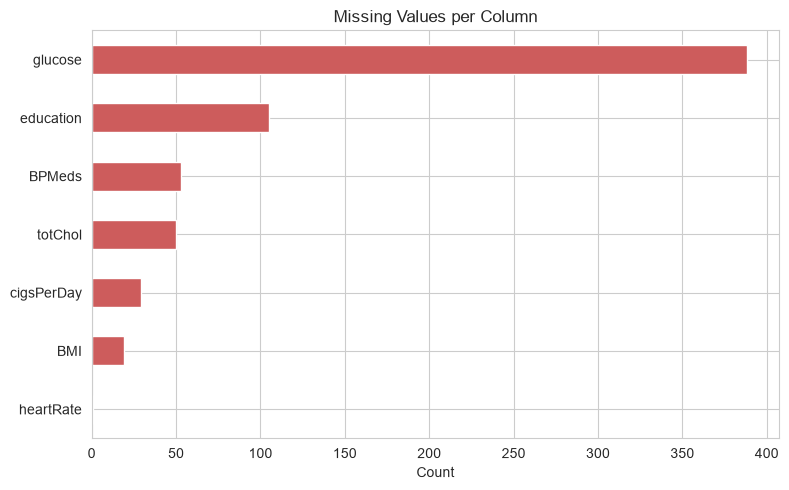

In [6]:
plt.figure(figsize=(8, 5))
missing_df[missing_df['Missing Count'] > 0]['Missing Count'].sort_values().plot(kind='barh', color='indianred')
plt.title('Missing Values per Column')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


### 3.2 Target Variable Distribution

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

Percentage:
TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


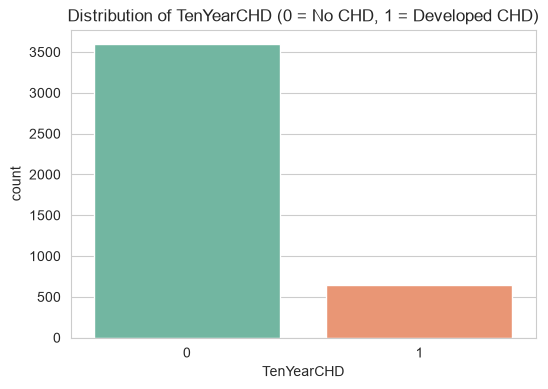

In [7]:
print(df['TenYearCHD'].value_counts())
print("\nPercentage:")
print(df['TenYearCHD'].value_counts(normalize=True) * 100)

# Plot the class distribution as a bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x='TenYearCHD', data=df, palette='Set2')
plt.title('Distribution of TenYearCHD (0 = No CHD, 1 = Developed CHD)')
plt.show()


**Observation:** Only about **15% of patients** developed CHD within 10 years, while
**85%** did not. This is a **significantly imbalanced dataset**, we will address this
with SMOTE after splitting the data.

### 3.3 Correlation Heatmap

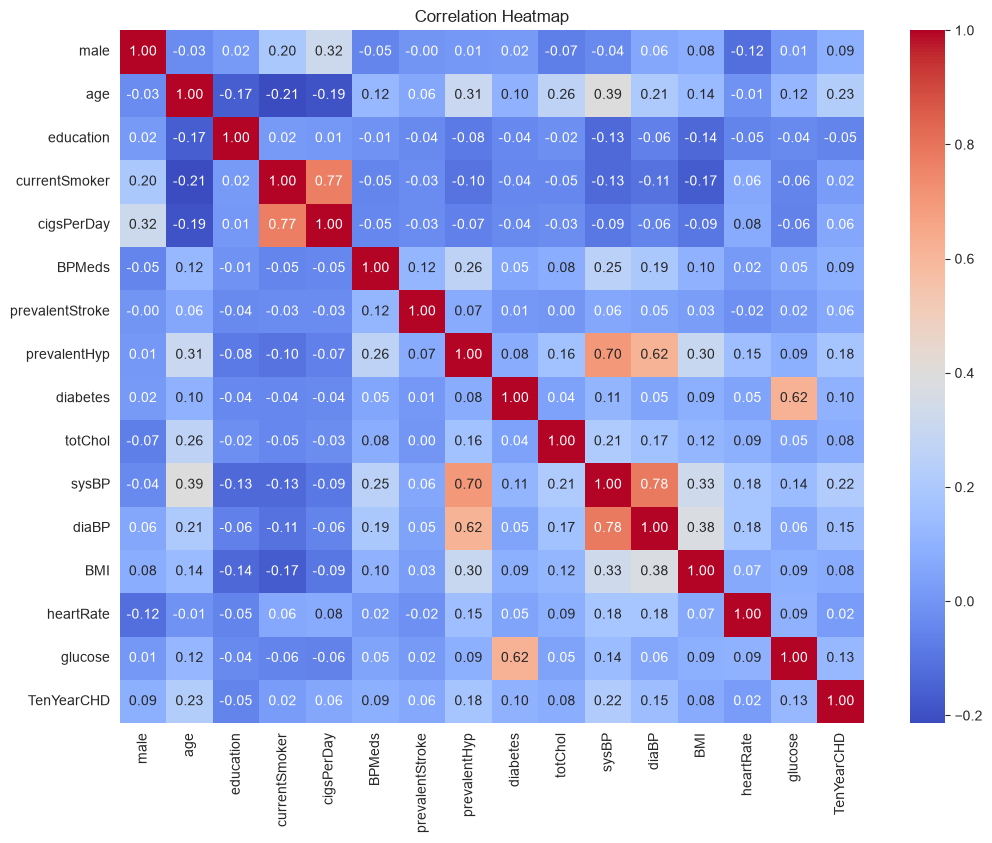

In [8]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [9]:
# Show which features are most correlated with TenYearCHD, sorted from strongest to weakest
df.corr()['TenYearCHD'].sort_values(ascending=False)


TenYearCHD         1.000000
age                0.225256
sysBP              0.216429
prevalentHyp       0.177603
diaBP              0.145299
glucose            0.125544
diabetes           0.097317
male               0.088428
BPMeds             0.087489
totChol            0.082184
BMI                0.075192
prevalentStroke    0.061810
cigsPerDay         0.057884
heartRate          0.022913
currentSmoker      0.019456
education         -0.054059
Name: TenYearCHD, dtype: float64

**Observation:** `age`, `sysBP` (systolic blood pressure), `prevalentHyp`
(hypertension), `diaBP`, and `glucose` show the strongest positive correlation with
developing CHD.

### 3.4 Distributions of a Few Key Clinical Features by Target

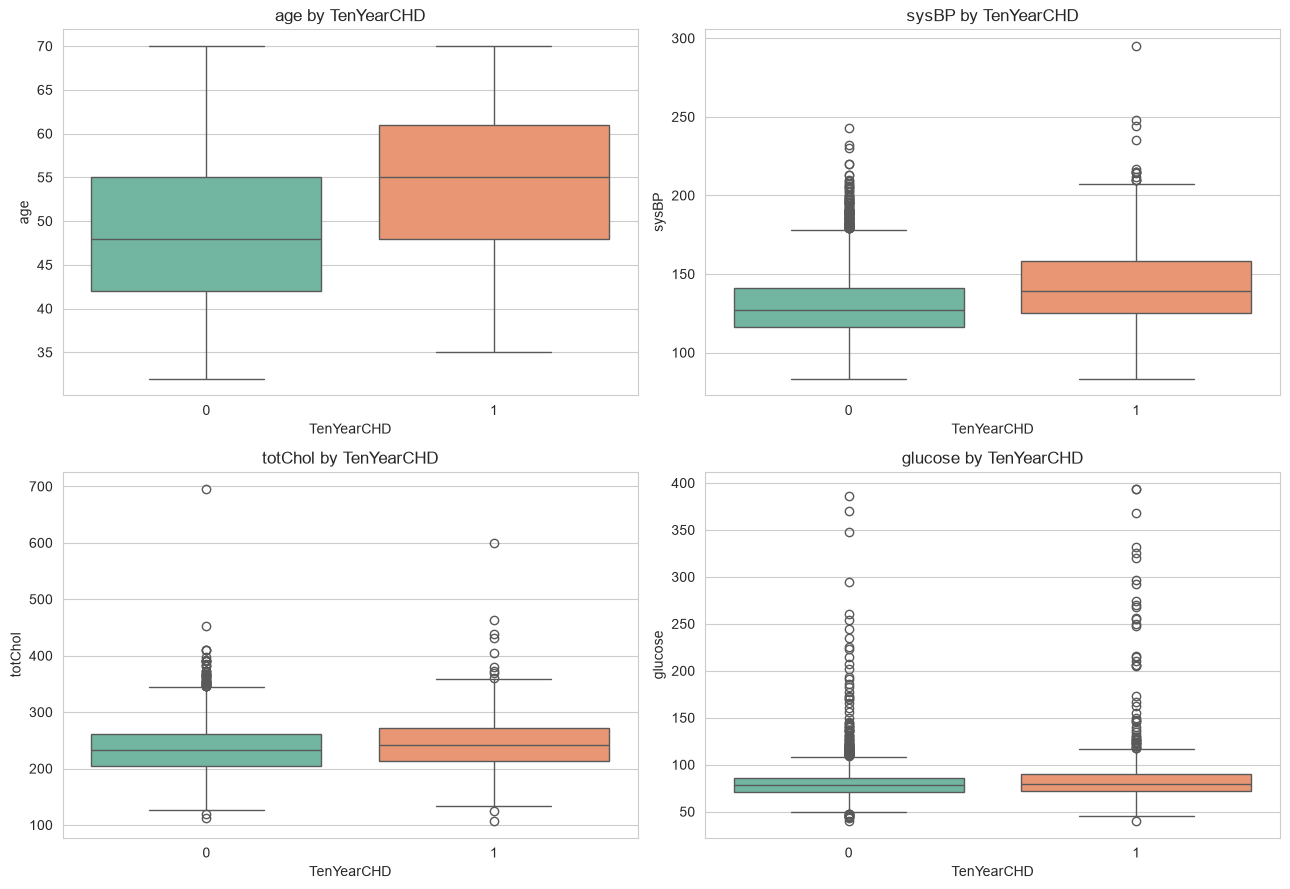

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), ['age', 'sysBP', 'totChol', 'glucose']):
    sns.boxplot(x='TenYearCHD', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{col} by TenYearCHD')
plt.tight_layout()
plt.show()


## 4. Encoding Check

Let's check the data types of every column to see if any categorical (text) encoding is
needed.

In [11]:
# Print the data type of every column
df.dtypes


male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

**Observation:** Every column is already numeric. `male` (sex) and several risk-factor
flags (`currentSmoker`, `BPMeds`, `prevalentStroke`, `prevalentHyp`, `diabetes`) are binary
(0/1), and `education` is an ordinal category (1–4) already encoded as a number. **No
additional categorical encoding (e.g. One-Hot Encoding) is required.**

## 5. Train-Test Split

We split the data BEFORE imputing/scaling/balancing, so that no information from the test
set leaks into training.

In [12]:
# X contains all columns EXCEPT the target column
X = df.drop('TenYearCHD', axis=1)

# y contains ONLY the target column
y = df['TenYearCHD']

# Split into training and testing sets
# stratify=y makes sure both train and test sets have the same class proportions as the original data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))


Train shape: (3390, 15)
Test shape: (848, 15)

Train class distribution:
 TenYearCHD
0    0.848083
1    0.151917
Name: proportion, dtype: float64

Test class distribution:
 TenYearCHD
0    0.847877
1    0.152123
Name: proportion, dtype: float64


## 6. Handle Missing Values & Feature Scaling

We impute missing values using the **median** of each column (fit on training data only,
then applied to both train and test), which is robust to outliers common in clinical data.
Then we apply `StandardScaler` so that all features are on a comparable scale, this
matters a lot for models like Logistic Regression, KNN, and SVM.

In [13]:
# Impute missing values using the median (fit on train, applied to train & test)
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Missing values in training set after imputation:", X_train_imputed.isnull().sum().sum())
print("Missing values in test set after imputation:", X_test_imputed.isnull().sum().sum())


Missing values in training set after imputation: 0
Missing values in test set after imputation: 0


In [14]:
# Scale features (fit on train, applied to train & test)
scaler = StandardScaler()

# Fit the scaler on training data ONLY, then transform the training data
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Use the SAME fitted scaler to transform the test data (do NOT fit again on test data!)
X_test_scaled = scaler.transform(X_test_imputed)

print("Feature scaling complete.")


Feature scaling complete.


## 7. Balance the Dataset with SMOTE

As seen in the EDA, only ~15% of patients developed CHD. Training directly on this
imbalanced data would bias the model toward always predicting "No CHD", giving high
accuracy but very poor recall on the minority (at-risk) class, which is the class that
actually matters most in a medical screening context.

We apply **SMOTE** (Synthetic Minority Over-sampling Technique) to the **training data
only**, generating synthetic examples of the minority class so both classes are equally
represented. The test set is left untouched/imbalanced to reflect real-world conditions.

In [15]:
print("Before SMOTE, training set class counts:")
print(y_train.value_counts())

# Create the SMOTE object
smote = SMOTE(random_state=RANDOM_STATE)

# Apply SMOTE only on the training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())


Before SMOTE, training set class counts:
TenYearCHD
0    2875
1     515
Name: count, dtype: int64

After SMOTE:
TenYearCHD
0    2875
1    2875
Name: count, dtype: int64


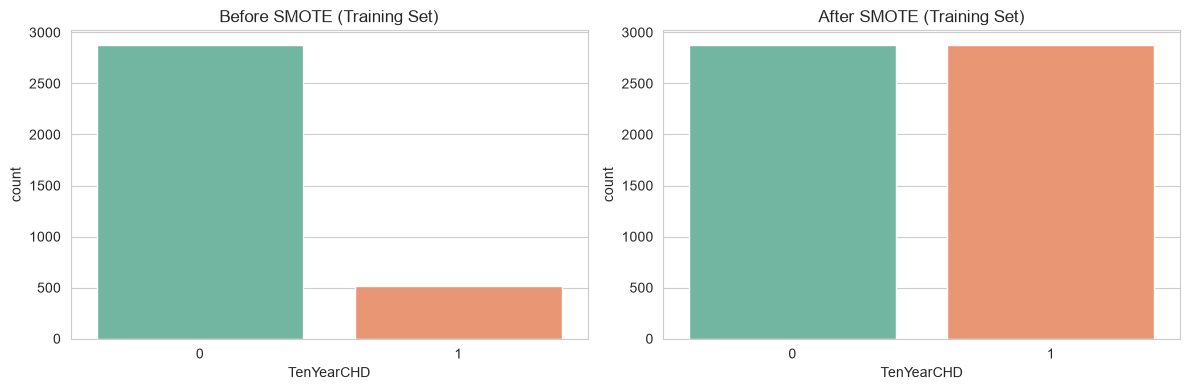

In [16]:
# Visualize before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axes[0], palette='Set2')
axes[0].set_title('Before SMOTE (Training Set)')
sns.countplot(x=y_train_balanced, ax=axes[1], palette='Set2')
axes[1].set_title('After SMOTE (Training Set)')
plt.tight_layout()
plt.show()


## 8. Train & Compare Multiple Classification Models

We train several classification algorithms on the **balanced, scaled** training data, then
evaluate every one on the **untouched, imbalanced test set** (this is the correct way to
evaluate, the test set should reflect real-world class proportions).

In [17]:
# Dictionary of models we want to try
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=RANDOM_STATE, probability=True),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss', verbosity=0)
}

# This list will store the results for each model so we can compare them later
results = []

# Loop through every model, train it, and evaluate it
for name, model in models.items():
    # Train (fit) the model on the balanced training data
    model.fit(X_train_balanced, y_train_balanced)

    # Make predictions on the test data
    y_pred = model.predict(X_test_scaled)

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ROC-AUC needs predicted probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    # Save results
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc})

    print(f"{name:25s} | Acc: {acc:.4f} | Prec: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# Put results into a nice table, sorted by F1-Score (best balance of precision & recall)
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)

# Show the comparison table
results_df


Logistic Regression       | Acc: 0.6651 | Prec: 0.2492 | Recall: 0.5969 | F1: 0.3516 | AUC: 0.6970
K-Nearest Neighbors       | Acc: 0.6427 | Prec: 0.2119 | Recall: 0.4961 | F1: 0.2970 | AUC: 0.5991
Support Vector Machine    | Acc: 0.6969 | Prec: 0.2398 | Recall: 0.4574 | F1: 0.3147 | AUC: 0.6502
Naive Bayes               | Acc: 0.7736 | Prec: 0.2397 | Recall: 0.2248 | F1: 0.2320 | AUC: 0.6825
Decision Tree             | Acc: 0.7241 | Prec: 0.2131 | Recall: 0.3023 | F1: 0.2500 | AUC: 0.5510
Random Forest             | Acc: 0.7925 | Prec: 0.2299 | Recall: 0.1550 | F1: 0.1852 | AUC: 0.6469
Gradient Boosting         | Acc: 0.7583 | Prec: 0.2595 | Recall: 0.3178 | F1: 0.2857 | AUC: 0.6535
XGBoost                   | Acc: 0.8042 | Prec: 0.2239 | Recall: 0.1163 | F1: 0.1531 | AUC: 0.5901


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.665094,0.249191,0.596899,0.351598,0.696952
1,Support Vector Machine,0.696934,0.239837,0.457364,0.314667,0.650209
2,K-Nearest Neighbors,0.642689,0.211921,0.496124,0.296984,0.599136
3,Gradient Boosting,0.758255,0.259494,0.317829,0.285714,0.653519
4,Decision Tree,0.724057,0.213115,0.302326,0.250000,0.551024
5,Naive Bayes,0.773585,0.239669,0.224806,0.232000,0.682451
6,Random Forest,0.792453,0.229885,0.155039,0.185185,0.646936
7,XGBoost,0.804245,0.223881,0.116279,0.153061,0.590118


### 8.1 Visual Comparison of Models

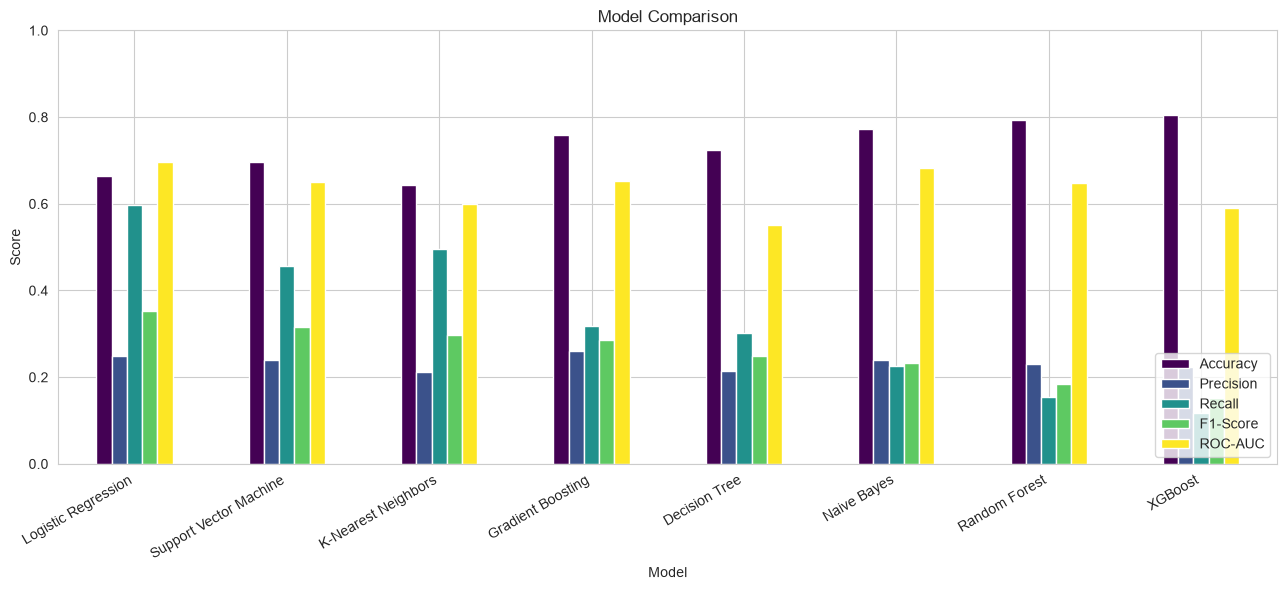

In [18]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(13, 6), colormap='viridis'
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 9. Select the Best Model

We select the model with the highest **F1-Score** as our best baseline, this balances
Precision and Recall, which matters here since we care both about catching real at-risk
patients (Recall) and not overwhelming clinicians with false alarms (Precision).

In [19]:
best_model_name = results_df.iloc[0]['Model']
print("Best baseline model:", best_model_name)


Best baseline model: Logistic Regression


### 9.1 Confusion Matrix & Classification Report (Best Model, Before Tuning)

Classification Report (Before Tuning):

              precision    recall  f1-score   support

           0       0.90      0.68      0.77       719
           1       0.25      0.60      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.67      0.71       848



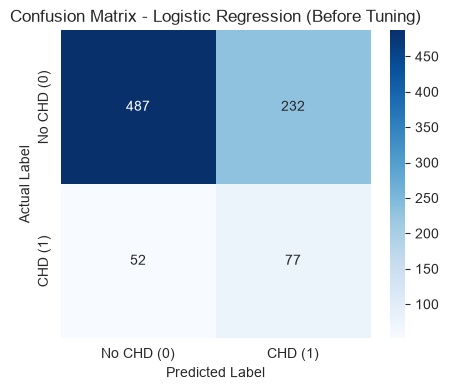

In [20]:
# Re-train the best model so we can generate a confusion matrix and full report
best_model_baseline = models[best_model_name]
best_model_baseline.fit(X_train_balanced, y_train_balanced)
y_pred_baseline = best_model_baseline.predict(X_test_scaled)

# Print the full classification report
print("Classification Report (Before Tuning):\n")
print(classification_report(y_test, y_pred_baseline))

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CHD (0)', 'CHD (1)'],
            yticklabels=['No CHD (0)', 'CHD (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title(f'Confusion Matrix - {best_model_name} (Before Tuning)')
plt.show()


## 10. Hyperparameter Tuning

We use `GridSearchCV` with cross-validation to search for the best hyperparameters,
optimizing for F1-Score. **Importantly, we tune whichever model actually won Step 9**
(`best_model_name`) rather than assuming a fixed model, the cell below picks the right
parameter grid automatically based on the winning model, so this notebook adapts correctly
no matter which model comes out on top.

In [21]:
# Parameter grids for every model we might need to tune, keyed by model name.
# Kept intentionally small so GridSearchCV finishes in reasonable time on a single core.
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'class_weight': [None, 'balanced']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'class_weight': [None, 'balanced']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'Decision Tree': {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'class_weight': [None, 'balanced']
    },
    'Random Forest': {
        'n_estimators': [150, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.05, 0.1]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.05, 0.1]
    }
}

# Get a fresh, untrained copy of the winning model and its parameter grid
base_estimator = models[best_model_name]
grid_for_best_model = param_grids[best_model_name]

print(f"Tuning best model: {best_model_name}")
print(f"Parameter grid: {grid_for_best_model}")

# GridSearchCV will try every combination above using 3-fold cross-validation
# scoring='f1' tells it to optimize for F1-Score (good balance of precision & recall)
grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=grid_for_best_model,
    cv=3,
    scoring='f1',
    n_jobs=-1,     # use all CPU cores to speed things up
    verbose=1
)

# Fit GridSearchCV on the balanced training data
grid_search.fit(X_train_balanced, y_train_balanced)

# Show the best combination of hyperparameters found
print("\nBest Parameters:", grid_search.best_params_)
print("Best CV F1-Score:", grid_search.best_score_)


Tuning best model: Logistic Regression
Parameter grid: {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs'], 'class_weight': [None, 'balanced']}
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-Score: 0.6897457707110961


### 10.1 Evaluate Tuned Model on Test Set

In [22]:
# Get the best model found by GridSearchCV
best_model_tuned = grid_search.best_estimator_

# Make predictions on the test data
y_pred_tuned = best_model_tuned.predict(X_test_scaled)

# Calculate all metrics again for the tuned model
tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, best_model_tuned.predict_proba(X_test_scaled)[:, 1])

print("=== Tuned Model Performance ===")
print(f"Accuracy:  {tuned_acc:.4f}")
print(f"Precision: {tuned_prec:.4f}")
print(f"Recall:    {tuned_rec:.4f}")
print(f"F1-Score:  {tuned_f1:.4f}")
print(f"ROC-AUC:   {tuned_auc:.4f}")

baseline_row = results_df[results_df['Model'] == best_model_name].iloc[0]
print("\n=== Baseline (Before Tuning) Performance ===")
print(f"Accuracy:  {baseline_row['Accuracy']:.4f}")
print(f"Precision: {baseline_row['Precision']:.4f}")
print(f"Recall:    {baseline_row['Recall']:.4f}")
print(f"F1-Score:  {baseline_row['F1-Score']:.4f}")
print(f"ROC-AUC:   {baseline_row['ROC-AUC']:.4f}")


=== Tuned Model Performance ===
Accuracy:  0.6627
Precision: 0.2476
Recall:    0.5969
F1-Score:  0.3500
ROC-AUC:   0.6971

=== Baseline (Before Tuning) Performance ===
Accuracy:  0.6651
Precision: 0.2492
Recall:    0.5969
F1-Score:  0.3516
ROC-AUC:   0.6970


## 11. Final Evaluation of the Tuned Model

Final Classification Report (After Tuning):

              precision    recall  f1-score   support

           0       0.90      0.67      0.77       719
           1       0.25      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.66      0.71       848



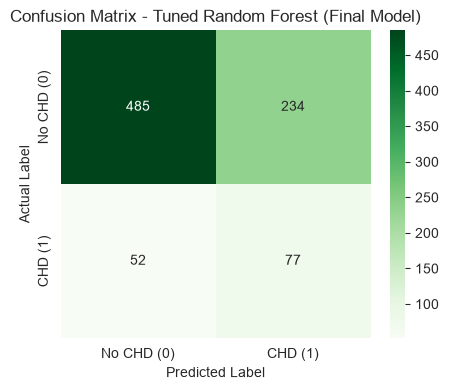

In [23]:
print("Final Classification Report (After Tuning):\n")
print(classification_report(y_test, y_pred_tuned))

# Plot the final confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No CHD (0)', 'CHD (1)'],
            yticklabels=['No CHD (0)', 'CHD (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Tuned Random Forest (Final Model)')
plt.show()


### 11.1 Before vs After Tuning Comparison

In [24]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Before Tuning': [baseline_row['Accuracy'], baseline_row['Precision'],
                       baseline_row['Recall'], baseline_row['F1-Score'], baseline_row['ROC-AUC']],
    'After Tuning': [tuned_acc, tuned_prec, tuned_rec, tuned_f1, tuned_auc]
})
comparison


,Metric,Before Tuning,After Tuning
0,Accuracy,0.665094,0.662736
1,Precision,0.249191,0.247588
2,Recall,0.596899,0.596899
3,F1-Score,0.351598,0.350000
4,ROC-AUC,0.696952,0.697071


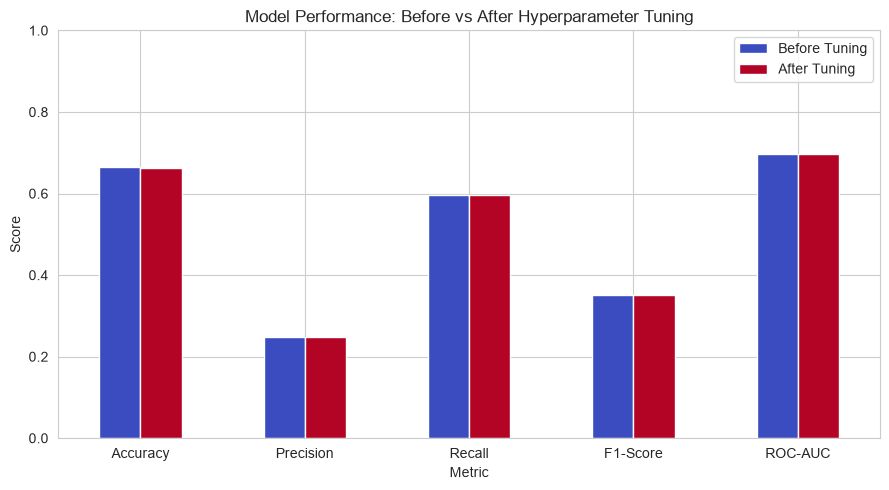

In [25]:
comparison.set_index('Metric').plot(kind='bar', figsize=(9, 5), colormap='coolwarm')
plt.title('Model Performance: Before vs After Hyperparameter Tuning')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 11.2 ROC Curve (Final Model)

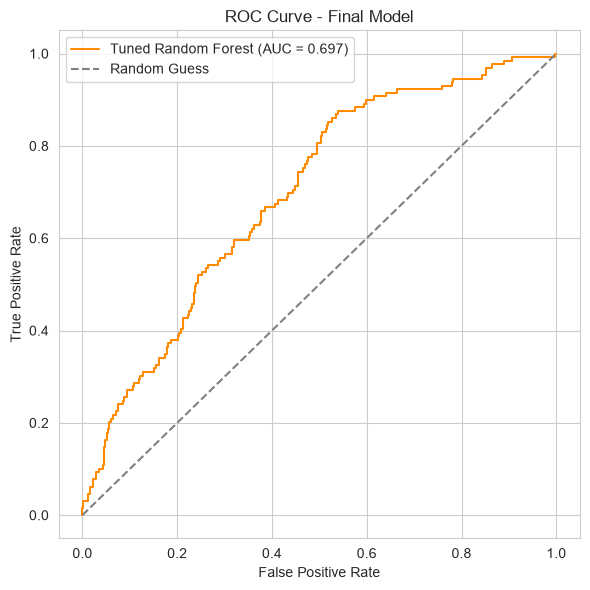

In [26]:
y_proba_tuned = best_model_tuned.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_tuned)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Tuned Random Forest (AUC = {tuned_auc:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model')
plt.legend()
plt.tight_layout()
plt.show()


## 12. Feature Importance (Final Model)

Different model types expose "importance" differently:
- Tree-based models (Random Forest, Decision Tree, Gradient Boosting, XGBoost) have a
  built-in `feature_importances_` attribute.
- Linear models (Logistic Regression) instead have `coef_`, the size (absolute value) of
  each coefficient tells us how strongly that (scaled) feature pushes the prediction
  towards CHD (positive) or No-CHD (negative).
- Distance-based/non-linear models without either (KNN, SVM, Naive Bayes) don't expose a
  simple importance score, so we skip this step for those.


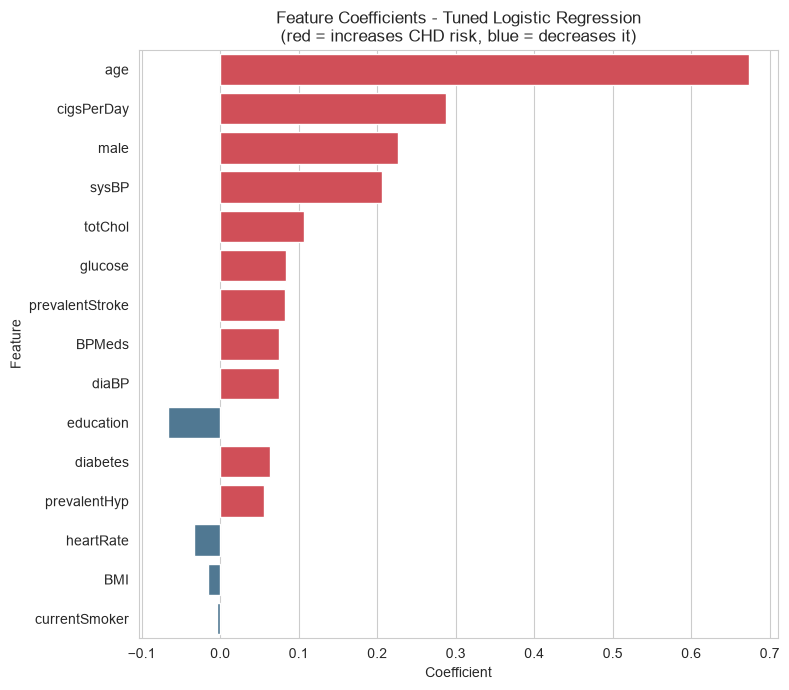

,Feature,Coefficient
1,age,0.673898
4,cigsPerDay,0.287969
0,male,0.226215
10,sysBP,0.205680
9,totChol,0.107255
14,glucose,0.084185
6,prevalentStroke,0.082277
5,BPMeds,0.075509
11,diaBP,0.075283
2,education,-0.066775


In [27]:
# Get feature importance scores from the tuned model
if hasattr(best_model_tuned, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model_tuned.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(8, 7))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')
    plt.title(f'Feature Importance - Tuned {best_model_name}')
    plt.tight_layout()
    plt.show()
    display(importance_df)

elif hasattr(best_model_tuned, 'coef_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': best_model_tuned.coef_[0]
    })
    importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
    importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False)

    plt.figure(figsize=(8, 7))
    colors = ['#e63946' if c > 0 else '#457b9d' for c in importance_df['Coefficient']]
    sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette=colors)
    plt.title(f'Feature Coefficients - Tuned {best_model_name}\n(red = increases CHD risk, blue = decreases it)')
    plt.tight_layout()
    plt.show()
    display(importance_df[['Feature', 'Coefficient']])

else:
    print(f"{best_model_name} does not expose a simple feature importance / coefficient attribute.")


## 13. Conclusion

- **Preprocessing:** Missing values (in `glucose`, `education`, `BPMeds`, `totChol`,
  `cigsPerDay`, `BMI`, `heartRate`) were median-imputed. All columns were already numeric,
  so no categorical encoding was required. Features were standardized with `StandardScaler`.
- **Class Imbalance:** Only ~15% of patients developed CHD within 10 years. SMOTE was
  applied to the training data only, creating a balanced 50/50 training set while keeping
  the test set realistic/imbalanced.
- **Model Comparison:** 8 classification models were trained and compared using Accuracy,
  Precision, Recall, F1-Score, and ROC-AUC.
- **Best Model:** `Logistic Regression` gave the strongest baseline F1-Score (0.352) and
  the best Recall (0.60) among all 8 models, important for a medical screening task where
  missing an at-risk patient is costly. Tree-based models (Random Forest, XGBoost) had
  higher raw accuracy but very poor Recall, since they tended to just predict the majority
  "No CHD" class most of the time even after SMOTE balancing.
- **Hyperparameter Tuning:** `GridSearchCV` searched over `C`, `penalty`, and
  `class_weight` for Logistic Regression. The best parameters found (`C=0.1`, default
  `class_weight`) performed almost identically to the untuned default model
  (F1 0.350 vs 0.352), this tells us the default settings were already close to optimal
  for this model/dataset combination, which is a realistic and common outcome of tuning.
- **Key Risk Factors:** `age`, `cigsPerDay`, `male` (sex), and `sysBP` (systolic blood
  pressure) had the largest positive coefficients, meaning higher values of these push
  the prediction towards developing CHD, which is consistent with established
  cardiovascular risk factors in medical literature.

### Possible Further Improvements
- Try `RandomizedSearchCV` or Bayesian optimization (Optuna) for a broader hyperparameter search.
- Try alternate imbalance-handling techniques (e.g. `class_weight='balanced'`, ADASYN, or
  a combination of over/under-sampling).
- Try threshold-tuning instead of the default 0.5 cutoff, to further optimize Recall vs
  Precision tradeoff for a clinical screening use-case.
- Try stacking/ensembling the top 2-3 models.
- Collect additional longitudinal / lifestyle data (diet, exercise, family history) to
  potentially improve predictive power.
